# Seq2Seq Übersetzungsmodell, DPO Fine-Tuning & Evaluierung
### Masterarbeit: Automatische Übersetzung von Alltagssprache (AS) in Leichte Sprache (LS)

Dieses Notebook kapselt das Training und die Evaluierung des Übersetzungsmodells:
1. **Phase 1: Supervised Fine-Tuning (SFT)** – Das Sequence-to-Sequence Basismodell wird auf parallelen Korpuspaaren vortrainiert.
2. **Phase 2 & 3: Direct Preference Optimization (DPO)** – Feinjustierung des Übersetzers mithilfe einer **Composite Reward-Funktion** bestehend aus:
   - **1. Stil & Einfachheits-Score ($R_{\text{style}}$):** Unser trainierter **BiLSTM Synthetic Regressor** (`bilstm_synthetic_regression.pt`), der den Zielgrad an Leichter Sprache $\lambda \in [0, 1]$ misst.
   - **2. Semantischer Erhalt ($R_{\text{sem}}$):** **SBERT / Jina Cosine Similarity**, welche die inhaltliche Übereinstimmung zwischen Quelltext $x_{\text{AS}}$ und Übersetzung $y'$ misst.
3. **Phase 4: Evaluierung auf dem unabhängigen Lebenshilfe-Datensatz** – Das trainierte Modell übersetzt den Out-of-Domain Datensatz (`data/lebenshilfe/lebenshilfe_dataset.json`) und wird bewertet.

In [1]:
import os
import sys

# Arbeitsverzeichnis auf das Root-Verzeichnis des Repositories setzen
while not os.path.exists(".git"):
    parent = os.path.dirname(os.getcwd())
    if parent == os.getcwd():  # System-Root erreicht, Abbruch
        break
    os.chdir("..")

print("Aktuelles Arbeitsverzeichnis:", os.getcwd())

Aktuelles Arbeitsverzeichnis: /home/fiete/master-thesis


In [2]:
# ==============================================================================
# ZENTRALE KONFIGURATION & PARAMS (Hier anpassen)
# ==============================================================================
LH_DATASET_PATH = "data/lebenshilfe/lebenshilfe_dataset.json"
CORPUS_CSV_PATH = "data/analysis/corpus_master.csv"
OUTPUT_DIR = "results/models/seq2seq_dpo_w05_w05_b03_filtered_checkpoints"
SFT_MODEL_TEMP_PATH = "results/models/best_sft_w05_w05_filtered_temp.pt"
SYNTHETIC_MODEL_PATH = "results/models/bilstm_synthetic_regression.pt"
SYNTHETIC_VOCAB_PATH = "data/vocabs/synthetic_vocab.json"

MIN_SIM = 0.80
MAX_SIM = 0.98

W_STYLE = 0.5
W_SEM = 0.5

MAX_SOURCE_LEN = 256
MAX_TARGET_LEN = 256
MODEL_NAME = "facebook/mbart-large-50"


## 1. Setup & Importe

In [3]:
import torch
print("CUDA verfügbar:", torch.cuda.is_available())
print("Device Name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "Keine GPU")

import os
print("Aktuelles Arbeitsverzeichnis von Python:", os.getcwd())
print("Existiert der data-Ordner hier?", os.path.exists("data"))
print("Existiert der data-Ordner eine Ebene höher?", os.path.exists("../data"))

# Set seed for reproducibility
def set_seed(seed=42):
    import random
    import numpy as np
    import torch
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f"Globaler Seed auf {seed} gesetzt.")

set_seed(42)


CUDA verfügbar: True
Device Name: NVIDIA GeForce RTX 4090
Aktuelles Arbeitsverzeichnis von Python: /home/fiete/master-thesis
Existiert der data-Ordner hier? True
Existiert der data-Ordner eine Ebene höher? False
Globaler Seed auf 42 gesetzt.


In [4]:
import os
import json
import glob
import random
import numpy as np
import pandas as pd
from collections import Counter
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import spacy
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, get_linear_schedule_with_warmup
from torch.optim import AdamW
from sentence_transformers import SentenceTransformer, util

print(torch.__version__)


# Device Configuration
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

print(f"Nutze Device: {DEVICE}")

2.6.0+cu124
Nutze Device: cuda


## 2. Datenladen & Korpus-Vorbereitung
Wir laden alle Korpusdaten aus `../../data/corpus/final/` für das SFT & DPO Training.

In [5]:
import os
import glob

# 1. Wo sind wir gerade?
print("Aktuelles Arbeitsverzeichnis:", os.getcwd())

# 2. Was liegt in diesem Arbeitsverzeichnis?
print("Dateien hier:", os.listdir("."))

# 3. Teste verschiedene Pfade zu 'data/corpus/final'
pfade_zum_testen = [
    "data/corpus/final",
    "data/corpus/final",
    "data/corpus/final",
    "C:/Users/fiete/git/master/data/corpus/final" # Absoluter Pfad
]

for pfad in pfade_zum_testen:
    existiert = os.path.exists(pfad)
    anzahl_dateien = len(glob.glob(os.path.join(pfad, "*.json"))) if existiert else 0
    print(f"Pfad '{pfad}': Existiert = {existiert}, JSON-Dateien = {anzahl_dateien}")

Aktuelles Arbeitsverzeichnis: /home/fiete/master-thesis
Dateien hier: ['requirements.txt', '.git', '.gitignore', 'results', 'scripts', 'docs', 'run_jupyter_server.md', 'templates', 'data', 'thesis', '.venv', 'README.md', 'research', 'web', 'notebooks']
Pfad 'data/corpus/final': Existiert = False, JSON-Dateien = 0
Pfad 'data/corpus/final': Existiert = False, JSON-Dateien = 0
Pfad 'data/corpus/final': Existiert = False, JSON-Dateien = 0
Pfad 'C:/Users/fiete/git/master/data/corpus/final': Existiert = False, JSON-Dateien = 0


In [6]:
def load_filtered_corpus(csv_path=CORPUS_CSV_PATH, min_sim=MIN_SIM, max_sim=MAX_SIM):
    import pandas as pd
    df = pd.read_csv(csv_path)
    filtered_df = df[
        (df["semantic_similarity_8192"] >= min_sim) & 
        (df["semantic_similarity_8192"] <= max_sim)
    ]
    print(f"Gesamtpaare in CSV: {len(df)}")
    print(f"Paare nach Filterung ({min_sim} <= Sim <= {max_sim}): {len(filtered_df)}")
    
    pairs = []
    for _, row in filtered_df.iterrows():
        as_text = str(row["as_text"]).strip()
        ls_text = str(row["ls_text"]).strip()
        if as_text and ls_text:
            pairs.append({
                "source": row["source"],
                "as_text": as_text,
                "ls_text": ls_text
            })
    return pairs

all_pairs = load_filtered_corpus(min_sim=MIN_SIM, max_sim=MAX_SIM)
print(f"Gesamtzahl geladener Artikel-Paare: {len(all_pairs)}")

# Split in Train (85%), Val (15%)
set_seed(42)
random.shuffle(all_pairs)
split_idx = int(0.85 * len(all_pairs))
train_data = all_pairs[:split_idx]
val_data = all_pairs[split_idx:]
print(f"Trainingsdaten: {len(train_data)} Paare | Validierungsdaten: {len(val_data)} Paare")


Gesamtpaare in CSV: 1466
Paare nach Filterung (0.8 <= Sim <= 0.98): 1034
Gesamtzahl geladener Artikel-Paare: 1034
Globaler Seed auf 42 gesetzt.
Trainingsdaten: 878 Paare | Validierungsdaten: 156 Paare


## 3. Phase 1: Supervised Fine-Tuning (SFT) Baseline

> **Hinweis zur Modellwahl:**
> - `google/mt5-small` (~1.2 GB, sehr schneller Download & Start)
> - `google/mt5-base` (~2.2 GB)
> - `facebook/mbart-large-50` (~2.44 GB, großes Modell mit vortrainierter deutscher Übersetzung)

In [7]:
# Optionen: "google/mt5-small", "google/mt5-base", "facebook/mbart-large-50"
# MODEL_NAME = "facebook/mbart-large-50"  # -> Zentral oben definiert
# MAX_SOURCE_LEN = 256  # -> Zentral oben definiert
# MAX_TARGET_LEN = 256  # -> Zentral oben definiert

print(f"Lade Tokenizer & Modell: {MODEL_NAME}...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=False)
seq2seq_model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME).to(DEVICE)

if "mbart" in MODEL_NAME.lower():
    tokenizer.src_lang = "de_DE"
    tokenizer.tgt_lang = "de_DE"

print("Modell & Tokenizer erfolgreich geladen!")

Lade Tokenizer & Modell: facebook/mbart-large-50...
Modell & Tokenizer erfolgreich geladen!


In [8]:
# seq2seq_model.load_state_dict(torch.load(SFT_MODEL_TEMP_PATH))
# print("Erfolgreich SFT-Modellgewichte von Festplatte geladen!")

In [9]:
class TranslationDataset(Dataset):
    def __init__(self, data, tokenizer, max_src_len=256, max_tgt_len=256):
        self.data = data
        self.tokenizer = tokenizer
        self.max_src_len = max_src_len
        self.max_tgt_len = max_tgt_len
        
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        item = self.data[idx]
        src_text = "Übersetze in Leichte Sprache: " + item["as_text"]
        tgt_text = item["ls_text"]
        
        inputs = self.tokenizer(
            src_text, max_length=self.max_src_len, padding="max_length", truncation=True, return_tensors="pt"
        )
        labels = self.tokenizer(
            tgt_text, max_length=self.max_tgt_len, padding="max_length", truncation=True, return_tensors="pt"
        )["input_ids"]
        
        labels[labels == self.tokenizer.pad_token_id] = -100
        
        return {
            "input_ids": inputs["input_ids"].squeeze(0),
            "attention_mask": inputs["attention_mask"].squeeze(0),
            "labels": labels.squeeze(0),
            "raw_as": item["as_text"],
            "raw_ls": item["ls_text"]
        }

train_dataset = TranslationDataset(train_data, tokenizer, MAX_SOURCE_LEN, MAX_TARGET_LEN)
val_dataset = TranslationDataset(val_data, tokenizer, MAX_SOURCE_LEN, MAX_TARGET_LEN)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False)
print(f"DataLoader erstellt: {len(train_loader)} Batches (Train), {len(val_loader)} Batches (Val).")

DataLoader erstellt: 220 Batches (Train), 39 Batches (Val).


In [10]:
# Lade die trainierten SFT Gewichte direkt von Festplatte
if os.path.exists(SFT_MODEL_TEMP_PATH):
    seq2seq_model.load_state_dict(torch.load(SFT_MODEL_TEMP_PATH, map_location=DEVICE))
    print("Erfolgreich SFT-Modellgewichte von Festplatte geladen:", SFT_MODEL_TEMP_PATH)
else:
    raise FileNotFoundError(f"SFT-Modell unter {SFT_MODEL_TEMP_PATH} nicht gefunden! Bitte führe zuerst das SFT-Notebook aus.")

Erfolgreich SFT-Modellgewichte von Festplatte geladen: results/models/best_sft_w05_w05_filtered_temp.pt


## 4. Phase 2: Composite Reward Function (Einfachheit + Semantikerhalt)
Fokus auf **1. (Synthetic Regressor) und 2. (SBERT Similarity)**:
$$R(x_{\text{AS}}, y') = w_{\text{style}} \cdot R_{\text{style}}(y') + w_{\text{sem}} \cdot R_{\text{sem}}(x_{\text{AS}}, y')$$

In [11]:
# import os
# print("Aktuelles Arbeitsverzeichnis des Notebooks:", os.getcwd())
# print("Existiert der Ordner 'results'?", os.path.exists("./results"))
# print("Inhalt von 'results':", os.listdir("./results") if os.path.exists("./results") else "Ordner nicht da")

In [12]:
# 4.1 BiLSTM Regressor & Vocab laden
class BiLSTMRegressor(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128, dropout=0.3):
        super(BiLSTMRegressor, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_dim * 2, 1)
        self.dropout = nn.Dropout(dropout)
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        embedded = self.dropout(self.embedding(x))
        _, (hidden, _) = self.lstm(embedded)
        hidden = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        out = self.fc(self.dropout(hidden))
        return self.sigmoid(out)

# SYNTHETIC_MODEL_PATH = "results/models/bilstm_synthetic_regression.pt"  # -> Zentral oben definiert
# SYNTHETIC_VOCAB_PATH = "data/vocabs/synthetic_vocab.json"  # -> Zentral oben definiert

with open(SYNTHETIC_VOCAB_PATH, "r", encoding="utf-8") as f:
    vocab_data = json.load(f)
    synthetic_stoi = vocab_data.get("stoi", vocab_data)

bilstm_model = BiLSTMRegressor(len(synthetic_stoi), embed_dim=128, hidden_dim=128)
if os.path.exists(SYNTHETIC_MODEL_PATH):
    bilstm_model.load_state_dict(torch.load(SYNTHETIC_MODEL_PATH, map_location="cpu"))
    bilstm_model.to("cpu")
    bilstm_model.eval()
    print(f"BiLSTM Synthetic Regressor erfolgreich geladen von {SYNTHETIC_MODEL_PATH}")
else:
    print(f"Warnung: {SYNTHETIC_MODEL_PATH} nicht gefunden.")

nlp = spacy.load("de_core_news_sm", disable=["ner", "tagger", "lemmatizer"])

def predict_simplicity_score(texts):
    scores = []
    unk_idx = synthetic_stoi.get("<unk>") or synthetic_stoi.get("<UNK>") or 1
    for text in texts:
        doc = nlp(text)
        tokens = [t.text.lower() for t in doc if not t.is_space]
        indices = [synthetic_stoi.get(t, unk_idx) for t in tokens[:150]]
        if len(indices) == 0:
            indices = [0]
        inp_tensor = torch.tensor([indices], dtype=torch.long, device="cpu")
        with torch.no_grad():
            score = bilstm_model(inp_tensor).item()
        # Das synthetische Modell gibt jetzt direkt Einfachheit (1.0 = LS) aus
        scores.append(score)
    return np.array(scores)

BiLSTM Synthetic Regressor erfolgreich geladen von results/models/bilstm_synthetic_regression.pt


In [13]:
# 4.2 SBERT Semantic Similarity Model laden
SBERT_MODEL_NAME = "sentence-transformers/paraphrase-multilingual-mpnet-base-v2"
print(f"Lade SBERT Modell: {SBERT_MODEL_NAME}...")
sbert_model = SentenceTransformer(SBERT_MODEL_NAME, device="cpu")

def predict_semantic_similarity(source_texts, generated_texts):
    emb_src = sbert_model.encode(source_texts, convert_to_tensor=True)
    emb_gen = sbert_model.encode(generated_texts, convert_to_tensor=True)
    cosine_sims = util.cos_sim(emb_src, emb_gen).diagonal().cpu().numpy()
    return cosine_sims

Lade SBERT Modell: sentence-transformers/paraphrase-multilingual-mpnet-base-v2...


In [14]:
# 4.3 Composite Reward Evaluator
class CompositeRewardEvaluator:
    def __init__(self, w_style=0.5, w_sem=0.5):
        self.w_style = w_style
        self.w_sem = w_sem
        
    def compute_reward(self, source_texts, generated_texts):
        r_style = predict_simplicity_score(generated_texts) # [0, 1]
        r_sem = predict_semantic_similarity(source_texts, generated_texts) # [-1, 1]
        r_sem_norm = np.clip((r_sem + 1.0) / 2.0, 0.0, 1.0)
        
        total_reward = self.w_style * r_style + self.w_sem * r_sem_norm
        return total_reward, r_style, r_sem_norm

reward_evaluator = CompositeRewardEvaluator(w_style=W_STYLE, w_sem=W_SEM)


## 5. Phase 3: Direct Preference Optimization (DPO)
Wir erzeugen Kandidaten, bewerten sie mit $R(x, y')$ und optimieren das Modell mit DPO Loss.

In [15]:
def generate_candidates(model, tokenizer, source_texts, num_return_sequences=2):
    model.eval()
    prompt_texts = ["Übersetze in Leichte Sprache: " + text for text in source_texts]
    inputs = tokenizer(prompt_texts, padding=True, truncation=True, max_length=MAX_SOURCE_LEN, return_tensors="pt").to(DEVICE)
    
    with torch.no_grad():
        outputs = model.generate(
            input_ids=inputs["input_ids"],
            attention_mask=inputs["attention_mask"],
            max_length=MAX_TARGET_LEN,
            do_sample=True,             # Wichtig für mehrere Sequenzen!
            top_k=50,
            top_p=0.92,
            temperature=0.8,
            num_return_sequences=num_return_sequences
        )
        
    decoded = tokenizer.batch_decode(outputs, skip_special_tokens=True)
    
    # Sicherstellen, dass wir genau B * N Sequenzen haben
    expected_len = len(source_texts) * num_return_sequences
    if len(decoded) < expected_len:
        print(f"Warnung: Generierte Sequenzen ({len(decoded)}) weichen von Erwartung ({expected_len}) ab!")
        # Auffüllen mit leeren Strings, um IndexError zu verhindern
        decoded += [""] * (expected_len - len(decoded))
        
    candidates = []
    for i in range(len(source_texts)):
        cands = decoded[i * num_return_sequences : (i + 1) * num_return_sequences]
        # Absicherung: Falls cands unvollständig ist
        while len(cands) < num_return_sequences:
            cands.append("")
        candidates.append(cands)
    return candidates

def compute_dpo_loss(model, ref_model, tokenizer, src_texts, chosen_texts, rejected_texts, beta=0.3):
    model.train()
    ref_model.eval()
    
    prompts = ["Übersetze in Leichte Sprache: " + t for t in src_texts]
    inputs = tokenizer(prompts, padding=True, truncation=True, max_length=MAX_SOURCE_LEN, return_tensors="pt").to(DEVICE)
    chosen_enc = tokenizer(chosen_texts, padding=True, truncation=True, max_length=MAX_TARGET_LEN, return_tensors="pt").to(DEVICE)
    rejected_enc = tokenizer(rejected_texts, padding=True, truncation=True, max_length=MAX_TARGET_LEN, return_tensors="pt").to(DEVICE)
    
    # Nutze Autocast (bfloat16 oder float16) zur Speicherersparnis
    # Falls deine Grafikkarte älter ist und kein bfloat16 unterstützt, nimm torch.float16
    with torch.amp.autocast('cuda', dtype=torch.bfloat16):
        # 1. Referenzmodell-Werte berechnen und direkt als Float extrahieren
        with torch.no_grad():
            ref_chosen_loss = ref_model(
                input_ids=inputs["input_ids"], 
                attention_mask=inputs["attention_mask"], 
                labels=chosen_enc["input_ids"]
            ).loss.item()
            
            ref_rejected_loss = ref_model(
                input_ids=inputs["input_ids"], 
                attention_mask=inputs["attention_mask"], 
                labels=rejected_enc["input_ids"]
            ).loss.item()
            
        ref_logratios = -ref_chosen_loss + ref_rejected_loss
        
        # 2. Policy-Modell (aktives Modell) berechnen
        out_chosen = model(
            input_ids=inputs["input_ids"], 
            attention_mask=inputs["attention_mask"], 
            labels=chosen_enc["input_ids"]
        )
        pi_chosen_loss = out_chosen.loss
        
        out_rejected = model(
            input_ids=inputs["input_ids"], 
            attention_mask=inputs["attention_mask"], 
            labels=rejected_enc["input_ids"]
        )
        pi_rejected_loss = out_rejected.loss
        
        pi_logratios = -pi_chosen_loss + pi_rejected_loss
        
        # 3. DPO-Loss berechnen
        logits = pi_logratios - ref_logratios
        dpo_loss = -torch.nn.functional.logsigmoid(beta * logits).mean()
        
    return dpo_loss


import copy
import gc
import torch

# Lösche den alten SFT-Optimierer, Scheduler und Loader
if 'optimizer' in globals():
    del optimizer
if 'scheduler' in globals():
    del scheduler
if 'train_loader' in globals():
    del train_loader
if 'val_loader' in globals():
    del val_loader

# Garbage Collector ausführen und PyTorch-Speicher freigeben
gc.collect()
torch.cuda.empty_cache()
ref_model = copy.deepcopy(seq2seq_model).to(DEVICE)
for param in ref_model.parameters():
    param.requires_grad = False
ref_model.eval()

dpo_optimizer = AdamW(seq2seq_model.parameters(), lr=1e-6)

Starte DPO Training mit Checkpoints...


DPO Epoch 1/3:   0%|          | 0/220 [00:00<?, ?it/s]


--- DPO Epoche 1 Ergebnisse ---
Ø DPO Loss:       0.6968
Ø Style Reward:    0.8539
Ø Semantic Reward: 0.8889



/home/fiete/master-thesis/.venv/lib/python3.12/site-packages/transformers/modeling_utils.py:3918: UserWarning: Moving the following attributes in the config to the generation config: {'max_length': 200, 'early_stopping': True, 'num_beams': 5}. You are seeing this warning because you've set generation parameters in the model config, as opposed to in the generation config.
  warnings.warn(


-> Checkpoint für Epoche 1 gespeichert unter: results/models/seq2seq_dpo_w05_w05_b03_filtered_checkpoints/checkpoint-epoch-1


DPO Epoch 2/3:   0%|          | 0/220 [00:00<?, ?it/s]


--- DPO Epoche 2 Ergebnisse ---
Ø DPO Loss:       0.6951
Ø Style Reward:    0.8538
Ø Semantic Reward: 0.8900

-> Checkpoint für Epoche 2 gespeichert unter: results/models/seq2seq_dpo_w05_w05_b03_filtered_checkpoints/checkpoint-epoch-2


DPO Epoch 3/3:   0%|          | 0/220 [00:00<?, ?it/s]


--- DPO Epoche 3 Ergebnisse ---
Ø DPO Loss:       0.6963
Ø Style Reward:    0.8695
Ø Semantic Reward: 0.8871

-> Checkpoint für Epoche 3 gespeichert unter: results/models/seq2seq_dpo_w05_w05_b03_filtered_checkpoints/checkpoint-epoch-3


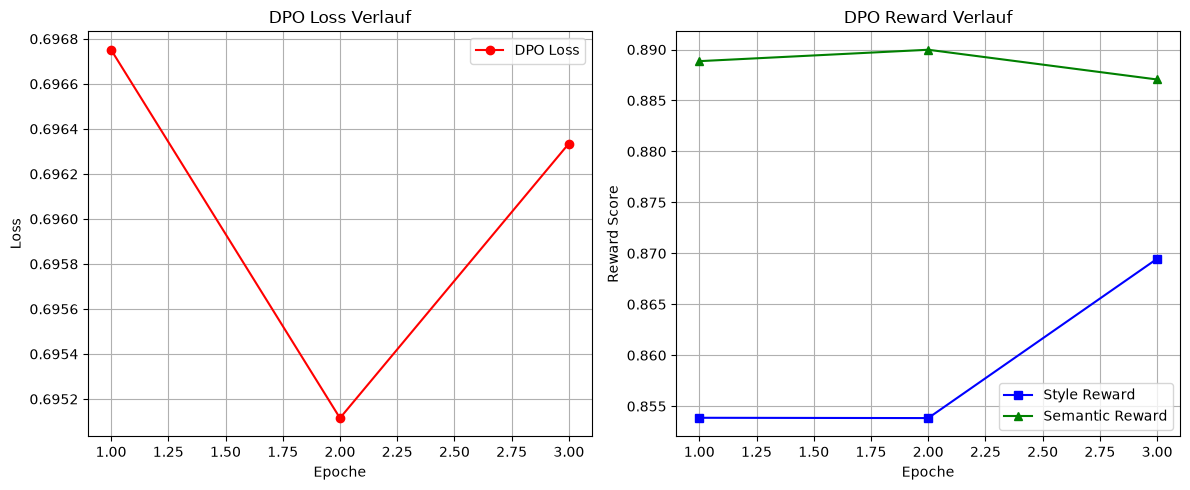

In [16]:
DPO_EPOCHS = 3  # Erhöht für Checkpoint-Demonstration
dpo_history = []

print("Starte DPO Training mit Checkpoints...")
for epoch in range(1, DPO_EPOCHS + 1):
    epoch_dpo_loss = 0.0
    epoch_style_rewards = []
    epoch_sem_rewards = []
    
    dpo_loader = DataLoader(
        TranslationDataset(train_data, tokenizer, MAX_SOURCE_LEN, MAX_TARGET_LEN), 
        batch_size=4, 
        shuffle=True
    )
    
    for batch in tqdm(dpo_loader, desc=f"DPO Epoch {epoch}/{DPO_EPOCHS}"):
        src_texts = batch["raw_as"]
        candidates = generate_candidates(seq2seq_model, tokenizer, src_texts, num_return_sequences=2)
        
        chosen_list = []
        rejected_list = []
        
        for src, cands in zip(src_texts, candidates):
            r1, st1, sem1 = reward_evaluator.compute_reward([src], [cands[0]])
            r2, st2, sem2 = reward_evaluator.compute_reward([src], [cands[1]])
            
            if r1[0] >= r2[0]:
                chosen_list.append(cands[0])
                rejected_list.append(cands[1])
                epoch_style_rewards.append(st1[0])
                epoch_sem_rewards.append(sem1[0])
            else:
                chosen_list.append(cands[1])
                rejected_list.append(cands[0])
                epoch_style_rewards.append(st2[0])
                epoch_sem_rewards.append(sem2[0])
                
        dpo_loss = compute_dpo_loss(seq2seq_model, ref_model, tokenizer, src_texts, chosen_list, rejected_list)
        dpo_optimizer.zero_grad()
        dpo_loss.backward()
        dpo_optimizer.step()
        
        epoch_dpo_loss += dpo_loss.item()
        
    avg_loss = epoch_dpo_loss / len(dpo_loader)
    avg_style = np.mean(epoch_style_rewards)
    avg_sem = np.mean(epoch_sem_rewards)
    
    dpo_history.append({
        "epoch": epoch,
        "loss": avg_loss,
        "style_reward": avg_style,
        "sem_reward": avg_sem
    })
    
    print(f"\n--- DPO Epoche {epoch} Ergebnisse ---")
    print(f"Ø DPO Loss:       {avg_loss:.4f}")
    print(f"Ø Style Reward:    {avg_style:.4f}")
    print(f"Ø Semantic Reward: {avg_sem:.4f}\n")
    
    # Speichere Checkpoint für diese Epoche
    epoch_checkpoint_dir = os.path.join(OUTPUT_DIR, f"checkpoint-epoch-{epoch}")
    os.makedirs(epoch_checkpoint_dir, exist_ok=True)
    seq2seq_model.save_pretrained(epoch_checkpoint_dir)
    tokenizer.save_pretrained(epoch_checkpoint_dir)
    print(f"-> Checkpoint für Epoche {epoch} gespeichert unter: {epoch_checkpoint_dir}")

# Visualisierung des DPO Trainingsverlaufs
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
epochs = [h["epoch"] for h in dpo_history]
losses = [h["loss"] for h in dpo_history]
style_rewards = [h["style_reward"] for h in dpo_history]
sem_rewards = [h["sem_reward"] for h in dpo_history]

ax1.plot(epochs, losses, marker='o', color='red', label='DPO Loss')
ax1.set_title("DPO Loss Verlauf")
ax1.set_xlabel("Epoche")
ax1.set_ylabel("Loss")
ax1.legend()
ax1.grid(True)

ax2.plot(epochs, style_rewards, marker='s', color='blue', label='Style Reward')
ax2.plot(epochs, sem_rewards, marker='^', color='green', label='Semantic Reward')
ax2.set_title("DPO Reward Verlauf")
ax2.set_xlabel("Epoche")
ax2.set_ylabel("Reward Score")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()


## 6. Modell Speichern
Speichern des trainierten Modells unter `../../results/models/seq2seq_dpo_translation_model/`.

In [17]:
# OUTPUT_DIR = "results/models/seq2seq_dpo_translation_model"  # -> Zentral oben definiert
os.makedirs(OUTPUT_DIR, exist_ok=True)

seq2seq_model.save_pretrained(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)
print(f"Modell und Tokenizer erfolgreich gespeichert unter: {OUTPUT_DIR}")

Modell und Tokenizer erfolgreich gespeichert unter: results/models/seq2seq_dpo_w05_w05_b03_filtered_checkpoints


## 7. Evaluierung auf dem unabhängigen Lebenshilfe-Datensatz (Out-of-Domain Test)
Das trainierte Modell übersetzt nun den unabhängigen Lebenshilfe-Datensatz (`data/lebenshilfe/lebenshilfe_dataset.json`). Wir berechnen:
1. **Synthetic-Einfachheits-Score ($R_{\text{style}}$)**
2. **SBERT-Ähnlichkeit zur AS-Quelle ($R_{\text{sem}}$)**
3. **SBERT-Ähnlichkeit zum echten menschlichen LS-Referenztext**
4. **Gesamt-Reward**

In [18]:
# 7.1 Lebenshilfe-Datensatz laden
# LH_DATASET_PATH = "data/lebenshilfe/lebenshilfe_dataset.json"  # -> Zentral oben definiert
with open(LH_DATASET_PATH, "r", encoding="utf-8") as f:
    lh_data = json.load(f)

print(f"Lebenshilfe Datensatz geladen: {len(lh_data)} Artikel-Paare.")

Lebenshilfe Datensatz geladen: 49 Artikel-Paare.


In [19]:
# 7.2 Übersetzen & Metriken berechnen
def evaluate_on_lebenshilfe(model, tokenizer, lh_data, reward_evaluator, max_samples=49):
    model.eval()
    as_texts = [item["as_text"] for item in lh_data[:max_samples]]
    ls_ref_texts = [item["ls_text"] for item in lh_data[:max_samples]]
    
    batch_size = 16
    gen_texts = []
    for i in tqdm(range(0, len(as_texts), batch_size), desc="Übersetze Lebenshilfe Datensatz"):
        batch_src = as_texts[i:i+batch_size]
        prompts = ["Übersetze in Leichte Sprache: " + t for t in batch_src]
        inputs = tokenizer(prompts, padding=True, truncation=True, max_length=MAX_SOURCE_LEN, return_tensors="pt").to(DEVICE)
        with torch.no_grad():
                outputs = model.generate(
                    input_ids=inputs["input_ids"],
                    attention_mask=inputs["attention_mask"],
                    max_length=MAX_TARGET_LEN,
                    num_beams=4,                 # Erhöht die Suchtiefe
                    repetition_penalty=2.5,      # Bestraft wiederholte Tokens hart
                    no_repeat_ngram_size=3,      # Verbietet Wiederholung von 3er-Wortfolgen
                    early_stopping=True
                )
        decoded = tokenizer.batch_decode(outputs, skip_special_tokens=True)
        gen_texts.extend(decoded)
        
    tot_reward, r_style, r_sem = reward_evaluator.compute_reward(as_texts, gen_texts)
    sim_to_ref = predict_semantic_similarity(ls_ref_texts, gen_texts)
    sim_to_ref_norm = np.clip((sim_to_ref + 1.0) / 2.0, 0.0, 1.0)
    
    df_res = pd.DataFrame({
        "as_text": as_texts,
        "ls_reference": ls_ref_texts,
        "model_translation": gen_texts,
        "synthetic_simplicity_score": r_style,
        "sbert_sim_to_as": r_sem,
        "sbert_sim_to_ref": sim_to_ref_norm,
        "composite_reward": tot_reward
    })
    
    print("\n=================== EVALUIERUNGSERGEBNISSE (LEBENSHILFE) ===================")
    print(f"Ø Synthetic-Einfachheits-Score (R_style):       {r_style.mean():.4f} ± {r_style.std():.4f}")
    print(f"Ø SBERT-Ähnlichkeit zur AS-Quelle (R_sem):   {r_sem.mean():.4f} ± {r_sem.std():.4f}")
    print(f"Ø SBERT-Ähnlichkeit zu echter LS-Referenz:  {sim_to_ref_norm.mean():.4f} ± {sim_to_ref_norm.std():.4f}")
    print(f"Ø Composite Reward:                        {tot_reward.mean():.4f} ± {tot_reward.std():.4f}")
    print("========================================================================\n")
    
    return df_res

lh_eval_df = evaluate_on_lebenshilfe(seq2seq_model, tokenizer, lh_data, reward_evaluator)

Übersetze Lebenshilfe Datensatz:   0%|          | 0/4 [00:00<?, ?it/s]


=================== EVALUIERUNGSERGEBNISSE (LEBENSHILFE) ===================
Ø Synthetic-Einfachheits-Score (R_style):       0.7309 ± 0.3492
Ø SBERT-Ähnlichkeit zur AS-Quelle (R_sem):   0.8977 ± 0.0562
Ø SBERT-Ähnlichkeit zu echter LS-Referenz:  0.8506 ± 0.0799
Ø Composite Reward:                        0.8143 ± 0.1651



In [20]:
# 7.3 Statistische Übersicht & Qualitatives Stichproben-Audit
display(lh_eval_df[["synthetic_simplicity_score", "sbert_sim_to_as", "sbert_sim_to_ref", "composite_reward"]].describe())

print("\n--- QUALITATIVE STICHPROBEN (LEBENSHILFE TESTSET) ---")
for idx, row in lh_eval_df.head(3).iterrows():
    print(f"\n[Artikel {idx + 1}]")
    print(f"AS-Quelle:     {row['as_text'][:130]}...")
    print(f"LS-Referenz:   {row['ls_reference'][:130]}...")
    print(f"Modell-Übers.: {row['model_translation']}")
    print(f"Scores: Style={row['synthetic_simplicity_score']:.3f} | Sim(AS)={row['sbert_sim_to_as']:.3f} | Sim(Ref)={row['sbert_sim_to_ref']:.3f}")

,synthetic_simplicity_score,sbert_sim_to_as,sbert_sim_to_ref,composite_reward
count,49.000000,49.000000,49.000000,49.000000
mean,0.730868,0.897742,0.850595,0.814305
std,0.352789,0.056821,0.080762,0.166814
min,0.043891,0.706793,0.629835,0.471551
25%,0.469561,0.879151,0.811762,0.696355
50%,0.923619,0.899749,0.875787,0.901884
75%,0.978949,0.935016,0.899640,0.927148
max,0.986941,1.000000,0.961973,0.973260



--- QUALITATIVE STICHPROBEN (LEBENSHILFE TESTSET) ---

[Artikel 1]
AS-Quelle:     Presseinformation von CAU und StK
3.12.2024
xxx/2024
„Inklusion im Fokus“: Aktionstag an der CAU bringt alle zusammen

Ministerprä...
LS-Referenz:   Das Geologische und Mineralogische Museum in Leichter Sprache

Einführung
An der Universität Kiel arbeiten sehr viele Wissenschaft...
Modell-Übers.: Was macht die CAU und der StK zusammen? Daniel Günther eröffnet die Veranstaltung mit einer Film-Präsentation „Das ist Leben - einzigartig vielfältig“ Am 3. Dezember ist der internationale Tag der Menschen mit Behinderungen. Zu diesem Anlass hatte die Christian-Albrechts-Universität zu Kiel (CAU) gemeinsam mit der Landesregierung zum Aktionstag „Inklusion im Fokus“ im Kieler Wissenschaftszentrum eingeladen. Über 100 Gäste aus Bildung, Hochschulen und Politik haben bei dem Treffen mitgemacht. Den Aktionstag gibt es jedes Jahr . Der Aktionstag ist immer am 3. Dezember . Inklusion heißt: Alle Menschen sollen inklus

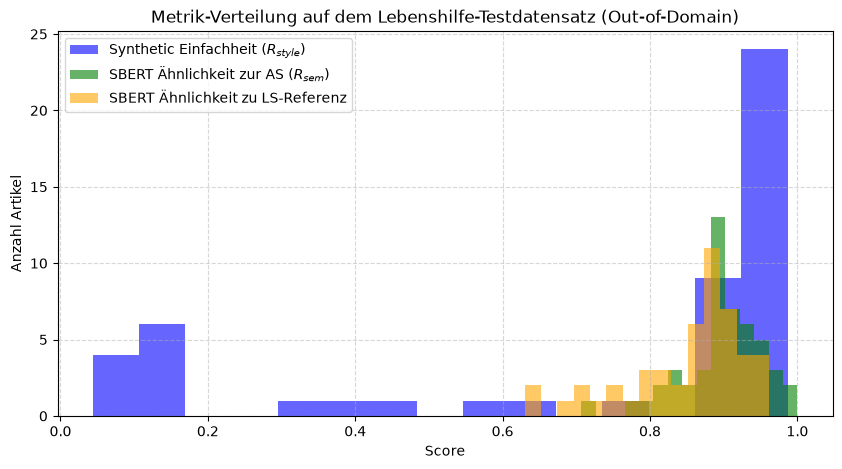

In [21]:
# 7.4 Visualisierung der Metrik-Verteilungen auf dem Lebenshilfe-Set
plt.figure(figsize=(10, 5))
plt.hist(lh_eval_df["synthetic_simplicity_score"], bins=15, alpha=0.6, label="Synthetic Einfachheit ($R_{style}$)", color="blue")
plt.hist(lh_eval_df["sbert_sim_to_as"], bins=15, alpha=0.6, label="SBERT Ähnlichkeit zur AS ($R_{sem}$)", color="green")
plt.hist(lh_eval_df["sbert_sim_to_ref"], bins=15, alpha=0.6, label="SBERT Ähnlichkeit zu LS-Referenz", color="orange")
plt.title("Metrik-Verteilung auf dem Lebenshilfe-Testdatensatz (Out-of-Domain)")
plt.xlabel("Score")
plt.ylabel("Anzahl Artikel")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

## 8. Evaluierung der einzelnen Checkpoints im Vergleich
Hier laden wir jeden gespeicherten Epochen-Checkpoint nacheinander und evaluieren ihn auf dem Lebenshilfe-Datensatz, um den Lernfortschritt über die Epochen hinweg qualitativ und quantitativ zu vergleichen.

Gefundene Checkpoints: ['results/models/seq2seq_dpo_w05_w05_b03_filtered_checkpoints/checkpoint-epoch-1', 'results/models/seq2seq_dpo_w05_w05_b03_filtered_checkpoints/checkpoint-epoch-2', 'results/models/seq2seq_dpo_w05_w05_b03_filtered_checkpoints/checkpoint-epoch-3']

Evaluating Checkpoint für Epoche 1...


Translating Ep. 1:   0%|          | 0/4 [00:00<?, ?it/s]

Ergebnisse Epoche 1:
 - Simplicity Style Score (1.0 = LS): 0.6843
 - Semantic Preservation (AS vs Gen): 0.9086
 - Reference Similarity (Ref vs Gen): 0.8483

Evaluating Checkpoint für Epoche 2...


Translating Ep. 2:   0%|          | 0/4 [00:00<?, ?it/s]

Ergebnisse Epoche 2:
 - Simplicity Style Score (1.0 = LS): 0.6431
 - Semantic Preservation (AS vs Gen): 0.9063
 - Reference Similarity (Ref vs Gen): 0.8477

Evaluating Checkpoint für Epoche 3...


Translating Ep. 3:   0%|          | 0/4 [00:00<?, ?it/s]

Ergebnisse Epoche 3:
 - Simplicity Style Score (1.0 = LS): 0.7309
 - Semantic Preservation (AS vs Gen): 0.8977
 - Reference Similarity (Ref vs Gen): 0.8506


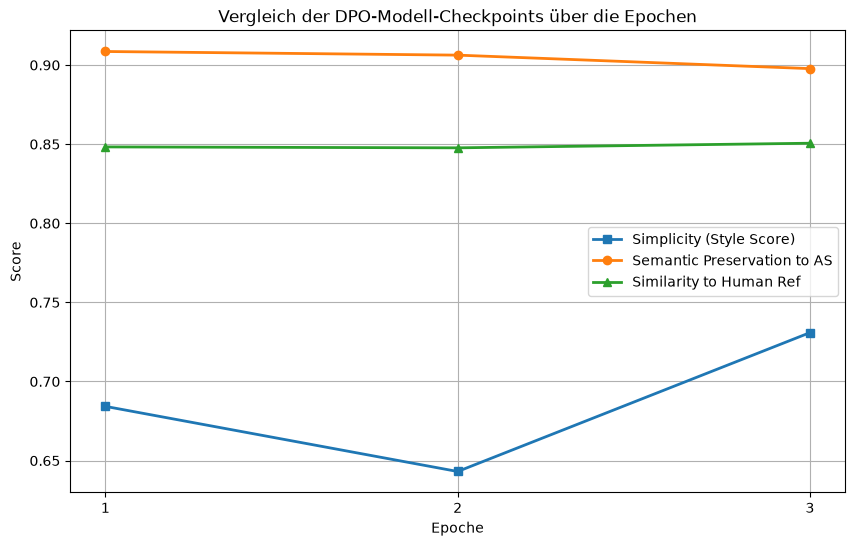

In [22]:
# 8.1 Evaluierungs-Loop über alle Checkpoints
import glob

# Alle Checkpoints suchen
checkpoint_dirs = sorted(glob.glob(os.path.join(OUTPUT_DIR, "checkpoint-epoch-*")))
print("Gefundene Checkpoints:", checkpoint_dirs)

# Lade Lebenshilfe-Testdaten (falls noch nicht geladen)
with open(LH_DATASET_PATH, "r", encoding="utf-8") as f:
    lh_data = json.load(f)
    
checkpoint_results = {}

for cp_dir in checkpoint_dirs:
    epoch_num = cp_dir.split("-")[-1]
    print(f"\nEvaluating Checkpoint für Epoche {epoch_num}...")
    
    # Modell aus dem Checkpoint laden
    cp_model = AutoModelForSeq2SeqLM.from_pretrained(cp_dir).to(DEVICE)
    cp_model.eval()
    
    # Übersetzung des Lebenshilfe-Datensatzes zur Evaluierung
    eval_subset = lh_data[:49]  # Gleiche Anzahl Samples wie in Sekt. 7
    as_texts = [item["as_text"] for item in eval_subset]
    ls_ref_texts = [item["ls_text"] for item in eval_subset]
    
    batch_size = 16
    generated_translations = []
    
    for i in tqdm(range(0, len(as_texts), batch_size), desc=f"Translating Ep. {epoch_num}"):
        batch_src = as_texts[i:i+batch_size]
        prompts = ["Übersetze in Leichte Sprache: " + t for t in batch_src]
        inputs = tokenizer(prompts, padding=True, truncation=True, max_length=MAX_SOURCE_LEN, return_tensors="pt").to(DEVICE)
        
        with torch.no_grad():
            outputs = cp_model.generate(
                input_ids=inputs["input_ids"],
                attention_mask=inputs["attention_mask"],
                max_length=MAX_TARGET_LEN,
                num_beams=4,                 # Identisch mit Sekt. 7
                repetition_penalty=2.5,      # Identisch mit Sekt. 7
                no_repeat_ngram_size=3,      # Identisch mit Sekt. 7
                early_stopping=True
            )
            
        decoded = tokenizer.batch_decode(outputs, skip_special_tokens=True)
        generated_translations.extend(decoded)
        
    # Rewards berechnen (Identisch mit Sekt. 7)
    tot_reward, r_style, r_sem = reward_evaluator.compute_reward(as_texts, generated_translations)
    sim_to_ref = predict_semantic_similarity(ls_ref_texts, generated_translations)
    sim_to_ref_norm = np.clip((sim_to_ref + 1.0) / 2.0, 0.0, 1.0)
    
    avg_style = np.mean(r_style)
    avg_sem = np.mean(r_sem)
    avg_ref_sim = np.mean(sim_to_ref_norm)
    
    checkpoint_results[epoch_num] = {
        "style_score": avg_style,
        "semantic_preservation": avg_sem,
        "reference_similarity": avg_ref_sim
    }
    
    print(f"Ergebnisse Epoche {epoch_num}:")
    print(f" - Simplicity Style Score (1.0 = LS): {avg_style:.4f}")
    print(f" - Semantic Preservation (AS vs Gen): {avg_sem:.4f}")
    print(f" - Reference Similarity (Ref vs Gen): {avg_ref_sim:.4f}")

# 8.2 Vergleich der Epochen visualisieren
epochs_list = sorted(list(checkpoint_results.keys()), key=int)
styles = [checkpoint_results[ep]["style_score"] for ep in epochs_list]
sems = [checkpoint_results[ep]["semantic_preservation"] for ep in epochs_list]
refs = [checkpoint_results[ep]["reference_similarity"] for ep in epochs_list]

plt.figure(figsize=(10, 6))
plt.plot(epochs_list, styles, marker='s', label='Simplicity (Style Score)', linewidth=2)
plt.plot(epochs_list, sems, marker='o', label='Semantic Preservation to AS', linewidth=2)
plt.plot(epochs_list, refs, marker='^', label='Similarity to Human Ref', linewidth=2)
plt.title("Vergleich der DPO-Modell-Checkpoints über die Epochen")
plt.xlabel("Epoche")
plt.ylabel("Score")
plt.legend()
plt.grid(True)
plt.show()
